In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

In [13]:
# Load dataset
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.fashion_mnist.load_data()

In [4]:
# Normalize
train_images = train_images / 255.0
test_images = test_images / 255.0


In [5]:
# Reshape for CNN
train_images = train_images.reshape((-1, 28, 28, 1))
test_images = test_images.reshape((-1, 28, 28, 1))


In [6]:
# CNN Model
model = models.Sequential([
    layers.Input(shape=(28,28,1)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])


In [7]:
# Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [8]:
# Train
history = model.fit(
    train_images,
    train_labels,
    epochs=5,
    validation_data=(test_images, test_labels)
)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 55s 29ms/step - accuracy: 0.8310 - loss: 0.4700 - val_accuracy: 0.8621 - val_loss: 0.3844
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 55s 30ms/step - accuracy: 0.8848 - loss: 0.3151 - val_accuracy: 0.8859 - val_loss: 0.3165
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 54s 29ms/step - accuracy: 0.8993 - loss: 0.2728 - val_accuracy: 0.8931 - val_loss: 0.2922
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 54s 29ms/step - accuracy: 0.9096 - loss: 0.2433 - val_accuracy: 0.9023 - val_loss: 0.2703
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 53s 28ms/step - accuracy: 0.9189 - loss: 0.2192 - val_accuracy: 0.9023 - val_loss: 0.2719


In [9]:
# Evaluate
loss, acc = model.evaluate(test_images, test_labels)
print("Accuracy:", acc)


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9023 - loss: 0.2719
Accuracy: 0.9023000001907349


In [10]:
# Predict one image
predictions = model.predict(test_images[:1])

print("Predicted Label:", np.argmax(predictions))
print("Actual Label:", test_labels[0])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
Predicted Label: 9
Actual Label: 9


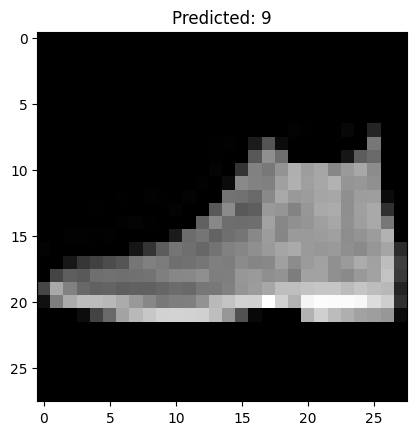

In [12]:
# Simple visual
plt.imshow(test_images[0].reshape(28,28), cmap='gray')
plt.title("Predicted: " + str(np.argmax(predictions)))
plt.show()